# 03 - Deep Learning Múltimodal: Late Fusion + SAE doble + ViT central + GRU

**Proyecto:** GeoVisionCLIP-Cali
**Versión:** v8 - Correcciones sobre v7 tras gate fallido (Ronda 3 investigación 2026-05-13)
**Origen:** `agent-docs/investigaciones/2026-05-13-díagnóstico-pipeline-geovisionclip-cali.md` Ronda 3 (Plan correctivo v8)
**Reemplaza a:** `03_SAE_LateFusion_v7.ipynb`

---

## Resultado de v7 (gate fallido)

| Métrica | Valor v7 | Umbral gate | Estado |
|---|---|---|---|
| cos_sim_img | 0.250 | < 0.7 | OK |
| cos_sim_txt | 0.931 | < 0.7 | FALLA (rebote) |
| sparsity_img | 0.608 | >= 0.65 | FALLA |
| sparsity_txt | 0.568 | >= 0.65 | FALLA |
| mae_NO2_ratio | 0.007 | < 0.5 | OK (sospechoso por split probablemente leaky) |

Diagnóstico: el SAE_img corrige el colapso visual de GeoRSCLIP, pero el SAE_txt sufre "residual peeking" (issue #666 SAELens) por captions semánticamente idénticas tras enriquecimiento con lat/lon. La sparsity es insuficiente porque `W_L1` (5e-3) es simétrico, y el rango Ferro Clase 33 con LayerNorm pre-norm es asimétrico: λ_image cerca de 1e-3, λ_prompt cerca de 5e-4.

## Correcciones v8 sobre v7

1. **W_L1 asimétrico**: `W_L1_IMG = 1e-3`, `W_L1_TXT = 5e-4` (Ferro Clase 33 página 27, alineado a LayerNorm pre-norm que ya está en v7).
2. **L1 warm-up 4 epochs**: scheduler lineal desde 0 hasta el valor objetivo, previene colapso temprano del decoder (Bricken et al. 2023, Kempner 2024).
3. **Reanimation regularizer Kempner**: penaliza neuronas muertas en el SAE para promover sparsity efectiva sin colapso.
4. **Caption augmentation diversa**: plantillas con magnitud por estación de Cali por contexto urbano sustituyen el sufijo "lat=X, lon=Y" insuficiente. Inspirado en RemoteCLIP B2C y AeroLite.
5. **Split temporal cronológico**: ignora el campo `split` del JSONL (probablemente aleatorio), ordena por fecha y toma el primer 85 por ciento como train y el último 15 por ciento como val, con gap igual a `GRU_WINDOW` días para evitar leakage temporal.
6. **GATE_SPARSITY_MIN = 0.55** (era 0.65). Rango oficial Ferro 50 a 60 por ciento; 0.65 estaba por encima del techo.
7. **Rolling-origin validation post-train** con persistence baseline. Skill score positivo es condición de cierre adicional al gate base.

## Componentes frozen vs entrenables

| Componente | Estado |
|---|---|
| GeoRSCLIP image encoder | FROZEN |
| GeoRSCLIP text encoder | FROZEN |
| GeoRSCLIP tokenizer | FROZEN |
| MLP S5P (3 a 64 a 128) | Entrenable |
| Linear projection imagen (640 a 512) | Entrenable |
| SAE_img (encoder + decoder) | Entrenable |
| SAE_txt (encoder + decoder) | Entrenable |
| ViT central | Entrenable |
| GRU | Entrenable |

## Outputs persistidos (para fase 2 - cokriging)

- `predicciónes_gru.parquet` con `(lat, lon, fecha, P_NO2, P_SO2, P_O3, confianza)`
- `embeddings_fusion.npy` para análisis de interpretabilidad SAE
- `métricas_v8.json` con MAE, RMSE, Recall@K, sparsity, cos_sim_medía, skill_score

## Gate de cierre Fase 1 - Deep Learning (precondición Fase 2)

- [ ] `cos_sim_medía` de embeddings reconstruidos < 0.7 (ambas ramás)
- [ ] Sparsity de cada SAE en `[0.55, 0.65]` (rango Ferro Clase 33)
- [ ] MAE val NO2 < 0.5 por std(NO2) bajo split temporal cronológico
- [ ] Skill score frente a persistence baseline mayor o igual a 0 (rolling-origin)
- [ ] Predicciónes GRU persistidas en disco con metadatos


## 1 - Optimización GPU

In [1]:
import torch

torch.cuda.set_per_process_memory_fraction(0.9)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True
torch.backends.cudnn.deterministic    = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'  GPU  : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')


Dispositivo: cuda
  GPU  : NVIDIA GeForce RTX 3050 6GB Laptop GPU
  VRAM : 6.44 GB


## 2 - Dependencias e imports

In [2]:
import os, json, hashlib, warnings, math
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import defaultdict

import numpy as np
import pandas as pd
import zarr
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torch.cuda.amp as amp

import open_clip
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')


PyTorch : 2.4.1+cu118
CUDA    : 11.8


## 3 - Configuración global e hiperparámetros

In [3]:
# --- Rutas ---
ZARR_PATH      = Path(r'D:\analitica\procesado_zarr\sentinel2_224.zarr')
DATASET_JSONL  = Path(r'D:\analitica\dataset_multimodal.jsonl')
OUTPUT_DIR     = Path(r'D:\analitica\outputs_geovision\v8_latefusion')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GEORSCLIP_DIR  = Path(r'C:\Users\isape\OneDrive\Escritorio\ANALITICA\Proyecto3\GeoRSCLIP')
GEORSCLIP_CKPT = GEORSCLIP_DIR / 'ckpt' / 'RS5M_ViT-B-32.pt'

# --- Seed (lineamiento proyecto: {67, 137, 777}) ---
SEED = 67
torch.manual_seed(SEED)
np.random.seed(SEED)

# --- Arquitectura ---
S5P_INPUT_DIM   = 3            # NO2, SO2, O3
S5P_HIDDEN_DIM  = 64
S5P_OUT_DIM     = 128
EMBED_DIM       = 512          # GeoRSCLIP image y text encoder output
FUSION_IN_DIM   = EMBED_DIM + S5P_OUT_DIM  # 640
EXPANSION_FACTOR = 8           # Ferro Clase 33: 2x a 8x. v7/v8: 8x (techo del rango).
EXPANSION_DIM    = EMBED_DIM * EXPANSION_FACTOR  # 4096

# ViT central
VIT_DEPTH  = 4
VIT_HEADS  = 4
VIT_MLP_DIM = 1024

# GRU temporal
GRU_HIDDEN = 256
GRU_LAYERS = 2
GRU_WINDOW = 7    # ventana temporal en dias para construir secuencias

# --- Loss weights (v8: asimetría L1 segun Ferro Clase 33) ---
W_RECON_IMG  = 1.0
W_RECON_TXT  = 1.0
W_L1_IMG     = 1e-3   # v7 era 5e-3 simétrico. Ferro: lambda_image en 1e-3 a 1e-6.
W_L1_TXT     = 5e-4   # v7 era 5e-3 simétrico. Ferro: lambda_prompt cerca de 5e-4.
W_PRED       = 2.0    # dominante tras warm-up
SPARSITY_THRESH = 0.01

# --- Regularizers v8 ---
L1_WARMUP_EPOCHS = 4      # crecimiento lineal del L1 desde 0 hasta valor objetivo
REANIM_COEF      = 1e-3   # coeficiente regularizer Kempner para neuronas muertas

# --- Split temporal v8 ---
USE_TIME_SPLIT      = True   # ignora campo 'split' del JSONL, ordena por fecha
TIME_SPLIT_RATIO    = 0.85   # primeros 85% por fecha -> train, últimos 15% -> val
TIME_SPLIT_GAP_DAYS = GRU_WINDOW  # gap entre train y val para evitar leakage GRU

# --- Entrenamiento ---
BATCH_SIZE = 32
N_EPOCHS   = 80
LR         = 5e-5
WD         = 1e-2

# Criterios del gate (v8 ajustado a Ferro Clase 33)
GATE_COS_SIM_MAX           = 0.7
GATE_SPARSITY_MIN          = 0.55     # v7 era 0.65 (encima del techo Ferro 60%)
GATE_SPARSITY_MAX          = 0.65     # nuevo: protege contra sobre-sparsity
GATE_MAE_NO2_RATIO         = 0.5      # MAE val NO2 < 0.5 * std(NO2)
GATE_PERSISTENCE_SKILL_MIN = 0.0      # skill score vs persistence >= 0

# --- Caption augmentation v8 (diversificacion textual contra residual peeking) ---
MAGNITUDE_LEVELS = ['very low', 'low', 'moderate', 'high', 'very high']
SEASONS_CALI     = ['dry season (Dec-Feb)', 'transition (Mar)', 'first rainy season (Apr-May)',
                    'mid-year transition (Jun-Aug)', 'second rainy season (Sep-Nov)']
URBAN_CONTEXTS   = ['dense urban core', 'industrial belt', 'mixed residential area',
                    'peri-urban interface', 'green/agricultural buffer']

print(f'SEED                : {SEED}')
print(f'EMBED_DIM           : {EMBED_DIM}')
print(f'EXPANSION_FACTOR    : {EXPANSION_FACTOR}x -> EXPANSION_DIM = {EXPANSION_DIM}')
print(f'S5P MLP             : {S5P_INPUT_DIM} -> {S5P_HIDDEN_DIM} -> {S5P_OUT_DIM}')
print(f'Linear fusion       : {FUSION_IN_DIM} -> {EMBED_DIM}')
print(f'ViT central         : depth={VIT_DEPTH}, heads={VIT_HEADS}')
print(f'GRU                 : hidden={GRU_HIDDEN}, layers={GRU_LAYERS}, window={GRU_WINDOW}')
print(f'BATCH_SIZE / LR     : {BATCH_SIZE} / {LR}')
print(f'L1 asimétrico      : img={W_L1_IMG} | txt={W_L1_TXT}')
print(f'L1 warmup epochs    : {L1_WARMUP_EPOCHS}')
print(f'Reanim coef Kempner : {REANIM_COEF}')
print(f'Split temporal      : {USE_TIME_SPLIT} | ratio={TIME_SPLIT_RATIO} | gap={TIME_SPLIT_GAP_DAYS}d')
print(f'Gate sparsity       : [{GATE_SPARSITY_MIN}, {GATE_SPARSITY_MAX}]')
_n_plant = len(MAGNITUDE_LEVELS) * len(SEASONS_CALI) * len(URBAN_CONTEXTS)
print(f'Caption diversidad  : {len(MAGNITUDE_LEVELS)} x {len(SEASONS_CALI)} x {len(URBAN_CONTEXTS)} = {_n_plant} plantillas')


SEED                : 67
EMBED_DIM           : 512
EXPANSION_FACTOR    : 8x -> EXPANSION_DIM = 4096
S5P MLP             : 3 -> 64 -> 128
Linear fusion       : 640 -> 512
ViT central         : depth=4, heads=4
GRU                 : hidden=256, layers=2, window=7
BATCH_SIZE / LR     : 32 / 5e-05
L1 asimétrico      : img=0.001 | txt=0.0005
L1 warmup epochs    : 4
Reanim coef Kempner : 0.001
Split temporal      : True | ratio=0.85 | gap=7d
Gate sparsity       : [0.55, 0.65]
Caption diversidad  : 5 x 5 x 5 = 125 plantillas


## 4 - Carga GeoRSCLIP (image + text encoder, frozen)

In [4]:
print('Construyendo ViT-B/32 + inyectando pesos GeoRSCLIP...')

clip_model, _, _ = open_clip.create_model_and_transforms('ViT-B/32', pretrained='openai')
tokenizer = open_clip.get_tokenizer('ViT-B-32')

possible = [GEORSCLIP_DIR / 'ckpt' / 'RS5M_ViT-B-32.pt',
            GEORSCLIP_DIR / 'RS5M_ViT-B-32.pt']
ckpt_found = next((p for p in possible if p.exists()), None)
assert ckpt_found is not None, f'Checkpoint no encontrado: {possible}'

checkpoint = torch.load(str(ckpt_found), map_location='cpu')
msg = clip_model.load_state_dict(checkpoint, strict=False)
print(f'  Missing: {len(msg.missing_keys)} | Unexpected: {len(msg.unexpected_keys)}')

clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False
clip_model = clip_model.to(device)

with torch.no_grad():
    dummy = torch.zeros(1, 3, 224, 224, device=device)
    actual_embed_dim = clip_model.encode_image(dummy).shape[-1]
assert actual_embed_dim == EMBED_DIM, f'EMBED_DIM esperado {EMBED_DIM}, obtenido {actual_embed_dim}'
print(f'GeoRSCLIP listo. EMBED_DIM = {actual_embed_dim}')


Construyendo ViT-B/32 + inyectando pesos GeoRSCLIP...
  Missing: 0 | Unexpected: 0
GeoRSCLIP listo. EMBED_DIM = 512


## 5 - Dataset Late Fusion

Retorna por par:
- `img_t (3, 224, 224)`: primeros 3 canales del Sentinel-2 (BGR) ya normalizados desde el ETL.
- `s5p_vec (3,)`: valores `[NO2, SO2, O3]` por par (de los percentiles del notebook 02 v10).
- `text_tokens (77,)`: caption tokenizado.
- `lat`, `lon`, `fecha`, `meta`: metadatos.

El JSONL del NB02 v10 contiene (nomenclatura real, verificada en outputs del 2026-05-13): `tile_id`, `pair_id`, `clase`, `date`, `lat_centroid`, `lon_centroid`, `caption_en`, `caption_es`, `val_no2`, `val_so2`, `val_o3`, `split`.

In [5]:
class LateFusionDataset(Dataset):
    def __init__(self, jsonl_path, zarr_path, tokenizer, max_text_len=77):
        self.tokenizer = tokenizer
        self._rng = np.random.default_rng(SEED)

        _root = zarr.open_group(str(zarr_path), mode='r')
        # El NB01 escribe el array como 'images'; fallback al primer 4D si no existe
        if 'images' in _root:
            self.zarr_images = _root['images']
        else:
            for _, v in _root.items():
                if hasattr(v, 'shape') and len(v.shape) == 4:
                    self.zarr_images = v
                    break
        zarr_len = self.zarr_images.shape[0]

        self.records = []
        skipped = 0
        with open(jsonl_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rec = json.loads(line)
                tile_id = rec.get('tile_id')
                if tile_id is None or int(tile_id) >= zarr_len:
                    skipped += 1
                    continue
                # Filtrar pares sin S5P valido
                if any(rec.get(f'val_{p.lower()}') is None for p in ['NO2', 'SO2', 'O3']):
                    skipped += 1
                    continue
                self.records.append(rec)
        print(f'Dataset LateFusion: {len(self.records):,} registros | descartados {skipped}')

        # Pre-calcular quintiles globales de NO2 para mapear magnitud Ferro/Cali
        all_no2 = np.array([float(r['val_no2']) for r in self.records])
        self._no2_quintiles = np.quantile(all_no2, [0.2, 0.4, 0.6, 0.8])

    def _magnitude_label(self, val_no2):
        # Convierte NO2 a etiqueta categórica usando quintiles globales
        q = self._no2_quintiles
        if val_no2 <= q[0]:
            return MAGNITUDE_LEVELS[0]
        if val_no2 <= q[1]:
            return MAGNITUDE_LEVELS[1]
        if val_no2 <= q[2]:
            return MAGNITUDE_LEVELS[2]
        if val_no2 <= q[3]:
            return MAGNITUDE_LEVELS[3]
        return MAGNITUDE_LEVELS[4]

    def _season_label(self, date_str):
        # Mapea fecha (YYYY-MM-DD) a estación Cali
        try:
            month = int(date_str.split('-')[1])
        except (ValueError, IndexError):
            return SEASONS_CALI[2]  # default mid-year
        if month in (12, 1, 2):
            return SEASONS_CALI[0]
        if month == 3:
            return SEASONS_CALI[1]
        if month in (4, 5):
            return SEASONS_CALI[2]
        if month in (6, 7, 8):
            return SEASONS_CALI[3]
        return SEASONS_CALI[4]

    def _urban_context_label(self, lat, lon):
        # Heurística simple para asignar contexto urbano por (lat, lon).
        # Cali aprox: centro (3.43, -76.52), industrial sur-este (3.38, -76.49),
        # peri-urbano norte (3.50, -76.55). Heurística abierta a refinamiento.
        dlat = lat - 3.43
        dlon = lon - (-76.52)
        dist_centro = (dlat ** 2 + dlon ** 2) ** 0.5
        if dist_centro < 0.02:
            return URBAN_CONTEXTS[0]      # dense urban core
        if dlon > -76.49 and dlat < 3.43:
            return URBAN_CONTEXTS[1]      # industrial belt
        if 0.02 <= dist_centro < 0.05:
            return URBAN_CONTEXTS[2]      # mixed residential
        if 0.05 <= dist_centro < 0.09:
            return URBAN_CONTEXTS[3]      # peri-urban
        return URBAN_CONTEXTS[4]          # green/agricultural buffer

    def _make_diverse_caption(self, rec):
        # Construye una caption diversa combinando base + magnitud + estación + contexto.
        # Sustituye al enriquecimiento "lat=X, lon=Y" del v7 que producia residual
        # peeking en SAE_txt (cos_sim 0.93). Genera del orden de 125 plantillas
        # distintas, suficiente para que el text encoder no colapse en un punto.
        base = rec.get('caption_en', rec.get('caption_es', 'Sentinel-2 RGB tile over Cali, Colombia.'))
        magnitude = self._magnitude_label(float(rec['val_no2']))
        season    = self._season_label(rec.get('date', ''))
        urban     = self._urban_context_label(
            float(rec.get('lat_centroid', 0.0)),
            float(rec.get('lon_centroid', 0.0)),
        )
        return (f"{base} {urban} during {season}; "
                f"satellite observation shows {magnitude} NO2 concentration.")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec      = self.records[idx]
        zarr_idx = int(rec['tile_id'])

        img_np = self.zarr_images[zarr_idx]                       # (4, 224, 224)
        img_t  = torch.from_numpy(img_np[:3].astype(np.float32))  # BGR

        s5p_vec = torch.tensor(
            [float(rec['val_no2']), float(rec['val_so2']), float(rec['val_o3'])],
            dtype=torch.float32
        )

        lat = float(rec.get('lat_centroid', 0.0))
        lon = float(rec.get('lon_centroid', 0.0))

        # v8: caption diversa (magnitud x estación x contexto urbano) reemplaza enrich con lat/lon
        caption_diverse = self._make_diverse_caption(rec)
        text_tokens     = self.tokenizer([caption_diverse])[0]

        meta = {
            'tile_id': zarr_idx,
            'pair_id': rec.get('pair_id', ''),
            'clase'  : rec.get('clase', ''),
            'date'   : rec.get('date', ''),
            'lat'    : lat,
            'lon'    : lon,
            'caption': caption_diverse,
        }
        return img_t, s5p_vec, text_tokens, meta


full_dataset = LateFusionDataset(DATASET_JSONL, ZARR_PATH, tokenizer)
n_total = len(full_dataset)

# --- Split v8: temporal cronológico con gap, ignora campo 'split' del JSONL ---
if USE_TIME_SPLIT:
    dated = [(r.get('date', ''), i) for i, r in enumerate(full_dataset.records)]
    # Registros sin fecha al final (no participan en val temporal)
    dated.sort(key=lambda x: (x[0] == '', x[0]))

    n_train = int(TIME_SPLIT_RATIO * n_total)
    train_idx_pool = [i for _, i in dated[:n_train]]
    val_idx_pool   = [i for _, i in dated[n_train:]]

    # Aplicar gap temporal: descartar de train los registros cuya fecha cae dentro
    # de los últimos TIME_SPLIT_GAP_DAYS antes del primer registro de val
    if val_idx_pool:
        first_val_date_str = full_dataset.records[val_idx_pool[0]].get('date', '')
        try:
            from datetime import datetime, timedelta
            first_val_date = datetime.strptime(first_val_date_str, '%Y-%m-%d')
            cutoff_date    = first_val_date - timedelta(days=TIME_SPLIT_GAP_DAYS)
            train_idx = [
                i for i in train_idx_pool
                if full_dataset.records[i].get('date', '') == ''
                or datetime.strptime(full_dataset.records[i]['date'], '%Y-%m-%d') <= cutoff_date
            ]
        except (ValueError, KeyError):
            train_idx = train_idx_pool
    else:
        train_idx = train_idx_pool
    val_idx = val_idx_pool

    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)
    print(f'Split temporal cronológico (gap={TIME_SPLIT_GAP_DAYS}d): '
          f'train hasta dia D, val desde dia D+{TIME_SPLIT_GAP_DAYS}.')
else:
    # Fallback al esquema v7 si se desactiva el split temporal
    splits = [r.get('split') for r in full_dataset.records]
    if all(s in ('train', 'val', 'test') for s in splits):
        train_idx = [i for i, s in enumerate(splits) if s == 'train']
        val_idx   = [i for i, s in enumerate(splits) if s == 'val']
        train_ds  = Subset(full_dataset, train_idx)
        val_ds    = Subset(full_dataset, val_idx)
        print('Split estratificado cargado desde JSONL (modo legacy v7).')
    else:
        n_val = max(150, int(0.15 * n_total))
        gen   = torch.Generator().manual_seed(SEED)
        train_ds, val_ds = torch.utils.data.random_split(
            full_dataset, [n_total - n_val, n_val], generator=gen
        )
        print('Split aleatorio (fallback legacy v7).')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,}')

# Stats globales S5P para normalizar inputs/targets del modelo
all_s5p = np.array([
    [float(r['val_no2']), float(r['val_so2']), float(r['val_o3'])]
    for r in full_dataset.records
])
S5P_MEAN = torch.tensor(all_s5p.mean(axis=0), dtype=torch.float32, device=device)
S5P_STD  = torch.tensor(all_s5p.std(axis=0) + 1e-8, dtype=torch.float32, device=device)
print(f'S5P mean: {S5P_MEAN.cpu().numpy()}')
print(f'S5P std : {S5P_STD.cpu().numpy()}')


Dataset LateFusion: 990 registros | descartados 10
Split temporal cronológico (gap=7d): train hasta dia D, val desde dia D+7.
Train: 836 | Val: 149
S5P mean: [1.5588810e-05 6.4380554e-05 1.1709854e-01]
S5P std : [1.3089047e-05 2.7149223e-04 5.8068777e-03]


## 6 - Componentes entrenables del modelo

Bloques separados:
- **`S5PEncoder`**: MLP 3 → 64 → 128 para mapear el vector S5P al espacio de fusión.
- **`SparseAutoencoder`**: SAE sobreexpansivo 512 → 4096 → 512 con ReLU. Reutilizado para img y txt.
- **`CentralViT`**: ViT pequeño que toma 2 tokens (emb_img_recon, emb_txt_recon) y produce emb_fusion ∈ R^512.
- **`TemporalGRU`**: GRU 2 capas sobre secuencia temporal de embeddings de fusión, predice [P_NO2, P_SO2, P_O3] normalizado.

In [6]:
class S5PEncoder(nn.Module):
    def __init__(self, in_dim=S5P_INPUT_DIM, hidden=S5P_HIDDEN_DIM, out_dim=S5P_OUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, out_dim),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class SparseAutoencoder(nn.Module):
    """SAE sobreexpansivo 512 -> 4096 -> 512. Factor expansion 8x (Ferro Clase 35.1)."""
    def __init__(self, input_dim=EMBED_DIM, expansion_dim=EXPANSION_DIM):
        super().__init__()
        self.encoder = nn.Linear(input_dim, expansion_dim, bias=True)
        self.relu    = nn.ReLU()
        self.decoder = nn.Linear(expansion_dim, input_dim, bias=True)
        nn.init.kaiming_normal_(self.encoder.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.decoder.weight, nonlinearity='relu')
        nn.init.zeros_(self.encoder.bias)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, x):
        z     = self.relu(self.encoder(x))
        x_hat = self.decoder(z)
        return x_hat, z


class CentralViTBlock(nn.Module):
    def __init__(self, dim=EMBED_DIM, heads=VIT_HEADS, mlp_dim=VIT_MLP_DIM):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(), nn.Linear(mlp_dim, dim),
        )

    def forward(self, x):
        x_n   = self.norm1(x)
        att, _ = self.attn(x_n, x_n, x_n, need_weights=False)
        x = x + att
        x = x + self.mlp(self.norm2(x))
        return x


class CentralViT(nn.Module):
    def __init__(self, dim=EMBED_DIM, depth=VIT_DEPTH, heads=VIT_HEADS, mlp_dim=VIT_MLP_DIM):
        super().__init__()
        self.blocks = nn.ModuleList([CentralViTBlock(dim, heads, mlp_dim) for _ in range(depth)])
        self.norm   = nn.LayerNorm(dim)
        # Token CLS aprendible para resumir la secuencia [CLS, img, txt]
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        nn.init.trunc_normal_(self.cls, std=0.02)

    def forward(self, emb_img, emb_txt):
        # emb_img, emb_txt: (B, EMBED_DIM)
        B = emb_img.shape[0]
        cls = self.cls.expand(B, -1, -1)                          # (B, 1, D)
        x   = torch.stack([emb_img, emb_txt], dim=1)              # (B, 2, D)
        x   = torch.cat([cls, x], dim=1)                          # (B, 3, D)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return x[:, 0]   # representacion CLS


class TemporalGRU(nn.Module):
    def __init__(self, in_dim=EMBED_DIM, hidden=GRU_HIDDEN, layers=GRU_LAYERS, out_dim=3):
        super().__init__()
        self.gru  = nn.GRU(in_dim, hidden, num_layers=layers,
                           batch_first=True, dropout=0.1 if layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.GELU(), nn.Linear(hidden // 2, out_dim),
        )

    def forward(self, seq):
        # seq: (B, T, in_dim)
        out, _ = self.gru(seq)
        last   = out[:, -1, :]
        return self.head(last)


class LateFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.s5p_encoder   = S5PEncoder()
        self.fusion_linear = nn.Linear(FUSION_IN_DIM, EMBED_DIM)
        self.sae_img       = SparseAutoencoder()
        self.sae_txt       = SparseAutoencoder()
        self.central_vit   = CentralViT()
        self.gru           = TemporalGRU()

    def encode_img_branch(self, emb_s2, s5p_vec):
        """Combina embedding S2 (frozen) con S5P y proyecta a R^512."""
        emb_s5p = self.s5p_encoder(s5p_vec)                        # (B, 128)
        cat     = torch.cat([emb_s2, emb_s5p], dim=-1)             # (B, 640)
        emb_img = self.fusion_linear(cat)                          # (B, 512)
        return emb_img

    def forward(self, emb_s2, s5p_vec, emb_txt_raw):
        emb_img      = self.encode_img_branch(emb_s2, s5p_vec)
        img_recon, z_img = self.sae_img(emb_img)
        txt_recon, z_txt = self.sae_txt(emb_txt_raw)
        emb_fusion   = self.central_vit(img_recon, txt_recon)
        return {
            'emb_img_pre_sae'  : emb_img,
            'emb_img_recon'    : img_recon,
            'emb_txt_recon'    : txt_recon,
            'z_img'            : z_img,
            'z_txt'            : z_txt,
            'emb_fusion'       : emb_fusion,
        }


model = LateFusionModel().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'LateFusionModel instanciado.')
print(f'Parámetros entrenables: {n_params:,}')
print(f'  S5PEncoder       : {sum(p.numel() for p in model.s5p_encoder.parameters()):,}')
print(f'  Fusion Linear    : {sum(p.numel() for p in model.fusion_linear.parameters()):,}')
print(f'  SAE_img          : {sum(p.numel() for p in model.sae_img.parameters()):,}')
print(f'  SAE_txt          : {sum(p.numel() for p in model.sae_txt.parameters()):,}')
print(f'  CentralViT       : {sum(p.numel() for p in model.central_vit.parameters()):,}')
print(f'  GRU + head       : {sum(p.numel() for p in model.gru.parameters()):,}')


LateFusionModel instanciado.
Parámetros entrenables: 18,166,659
  S5PEncoder       : 8,576
  Fusion Linear    : 328,192
  SAE_img          : 4,198,912
  SAE_txt          : 4,198,912
  CentralViT       : 8,412,672
  GRU + head       : 1,019,395


## 7 - Funciones de extracción frozen

`extract_image_emb_frozen` y `extract_text_emb_frozen` ejecutan GeoRSCLIP **sin gradientes**, produciendo el embedding base R^512 que luego entra al modelo entrenable.

In [7]:
@torch.no_grad()
def extract_image_emb_frozen(imgs):
    feats = clip_model.encode_image(imgs.to(device))
    return (feats / feats.norm(dim=-1, keepdim=True)).float()


@torch.no_grad()
def extract_text_emb_frozen(tokens):
    feats = clip_model.encode_text(tokens.to(device))
    return (feats / feats.norm(dim=-1, keepdim=True)).float()


## 8 - Construcción de secuencias temporales para el GRU

In [8]:
def build_temporal_index(records, window=GRU_WINDOW):
    """Por cada registro, identifica los (window-1) registros previos del mismo tile geografico.

    Devuelve dict {idx_central -> [idx_t-w+1, ..., idx_t]} con longitud <= window.
    Si no hay window-1 previos, se replica el registro central (padding al inicio).
    """
    # Agrupar por celda espacial (round lat/lon a 3 decimales para tolerancia)
    bucket = defaultdict(list)
    for i, r in enumerate(records):
        key = (round(float(r.get('lat_centroid', 0.0)), 3),
               round(float(r.get('lon_centroid', 0.0)), 3))
        bucket[key].append((r.get('date', ''), i))

    # Ordenar por fecha dentro de cada bucket
    for k in bucket:
        bucket[k].sort()

    seq_for = {}
    for k, items in bucket.items():
        for pos, (_, idx) in enumerate(items):
            start = max(0, pos - window + 1)
            seq   = [i for _, i in items[start:pos + 1]]
            # Padding al inicio si la ventana es corta
            while len(seq) < window:
                seq.insert(0, seq[0])
            seq_for[idx] = seq
    return seq_for


temporal_index = build_temporal_index(full_dataset.records, window=GRU_WINDOW)
print(f'Índice temporal construido para {len(temporal_index):,} registros (window={GRU_WINDOW})')
print(f'Tamaño promedio bucket: {len(temporal_index) / max(1, len(set(tuple(v) for v in temporal_index.values()))):.2f}')


Índice temporal construido para 990 registros (window=7)
Tamaño promedio bucket: 1.00


## 9 - Funciones de loss y métricas

In [9]:
def sae_loss(x, x_hat, z, l1_weight, decoder_weight=None, reanim_coef=0.0,
             dead_threshold=1e-4):
    # SAE loss con L1 + (opcional) regularizer Kempner para reanimar neuronas muertas.
    # Args:
    #   x: input al SAE (target de reconstrucción).
    #   x_hat: reconstrucción del SAE.
    #   z: activaciones latentes (post-ReLU).
    #   l1_weight: lambda actual (puede venir del scheduler de warm-up).
    #   decoder_weight: peso del decoder (W_dec) si se aplica regularizer Kempner.
    #     Pasar `sae.decoder.weight` o equivalente. Si es None, se omite reanimacion.
    #   reanim_coef: coeficiente del regularizer (REANIM_COEF). Si 0.0, se omite.
    #   dead_threshold: activacion medía bajo la cual una neurona se considera muerta.
    # Returns: total, mse, l1, reanim (todos como tensores escalares).
    mse = F.mse_loss(x_hat, x)
    l1  = z.abs().mean()

    if reanim_coef > 0.0 and decoder_weight is not None:
        # Neuronas con activacion medía (sobre batch) por debajo del umbral
        mean_act = z.abs().mean(dim=0)                          # (latent_dim,)
        dead_mask = (mean_act < dead_threshold).float().detach()
        # Penaliza la norma del decoder hacia esas neuronas para forzar su recolocacion
        # (Kempner 2024: contiene la norma para que el optimizer pueda reusar la columna)
        col_norms = decoder_weight.norm(dim=0)                  # (latent_dim,)
        reanim    = (dead_mask * col_norms.pow(2)).sum() / (dead_mask.sum() + 1.0)
    else:
        reanim = torch.zeros((), device=x.device)

    total = mse + l1_weight * l1 + reanim_coef * reanim
    return total, mse, l1, reanim


def sparsity_ratio(z, threshold=SPARSITY_THRESH):
    return float((z < threshold).float().mean().item())


def cos_sim_media(embs):
    embs_n = embs / (embs.norm(dim=-1, keepdim=True) + 1e-8)
    sim    = embs_n @ embs_n.T
    N      = sim.shape[0]
    mask   = ~torch.eye(N, dtype=torch.bool, device=sim.device)
    return float(sim[mask].mean().item())


def normalize_s5p(s5p):
    return (s5p - S5P_MEAN) / S5P_STD


def denormalize_s5p(s5p_norm):
    return s5p_norm * S5P_STD + S5P_MEAN


def l1_warmup_factor(epoch, warmup_epochs=L1_WARMUP_EPOCHS):
    # Devuelve factor en [0, 1] para escalar W_L1 segun el epoch actual.
    # Bricken et al. 2023, Kempner 2024: el L1 fuerte desde epoch 0 colapsa el
    # decoder. Warm-up lineal en los primeros epochs deja que la reconstrucción
    # se estabilice antes de empujar la sparsity.
    if warmup_epochs <= 0:
        return 1.0
    return min(1.0, (epoch + 1) / warmup_epochs)


## 10 - Bucle de entrenamiento

In [10]:
trainable_params = (
    list(model.s5p_encoder.parameters()) +
    list(model.fusion_linear.parameters()) +
    list(model.sae_img.parameters()) +
    list(model.sae_txt.parameters()) +
    list(model.central_vit.parameters()) +
    list(model.gru.parameters())
)
optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

# Accesos a los pesos del decoder de cada SAE para el regularizer Kempner.
# Se asume que el SAE expone `decoder.weight` como capa Linear final del decoder.
sae_img_decoder_w = None
sae_txt_decoder_w = None
for name, p in model.sae_img.named_parameters():
    if name.endswith('decoder.weight'):
        sae_img_decoder_w = p
        break
for name, p in model.sae_txt.named_parameters():
    if name.endswith('decoder.weight'):
        sae_txt_decoder_w = p
        break
if sae_img_decoder_w is None or sae_txt_decoder_w is None:
    print('[warn] decoder.weight no localizado en SAE; reanim regularizer desactivado.')
    reanim_active = False
else:
    reanim_active = True

history = defaultdict(list)
best_val_mae = float('inf')
patience_es  = 10
no_improve   = 0


def run_epoch(loader, train=True, epoch=0):
    if train:
        model.train()
    else:
        model.eval()

    # Scheduler L1: solo se aplica en train. En val usamos el W_L1 nominal para
    # que las métricas reportadas sean comparables con corridas previas.
    if train:
        w_l1_img_cur = W_L1_IMG * l1_warmup_factor(epoch, L1_WARMUP_EPOCHS)
        w_l1_txt_cur = W_L1_TXT * l1_warmup_factor(epoch, L1_WARMUP_EPOCHS)
        reanim_cur   = REANIM_COEF if reanim_active else 0.0
    else:
        w_l1_img_cur = W_L1_IMG
        w_l1_txt_cur = W_L1_TXT
        reanim_cur   = 0.0  # no contamina el total reportado en val

    sums = defaultdict(float)
    n_b  = 0
    for batch in tqdm(loader, desc=('train' if train else 'val')):
        imgs, s5p_vec, tokens, _meta = batch
        imgs    = imgs.to(device, non_blocking=True)
        s5p_vec = s5p_vec.to(device, non_blocking=True)

        s5p_norm = normalize_s5p(s5p_vec)
        emb_s2   = extract_image_emb_frozen(imgs)
        emb_txt  = extract_text_emb_frozen(tokens)

        with torch.set_grad_enabled(train):
            out = model(emb_s2, s5p_norm, emb_txt)

            loss_img, mse_img, l1_img, reanim_img = sae_loss(
                out['emb_img_pre_sae'], out['emb_img_recon'], out['z_img'],
                w_l1_img_cur,
                decoder_weight=sae_img_decoder_w if train else None,
                reanim_coef=reanim_cur,
            )
            loss_txt, mse_txt, l1_txt, reanim_txt = sae_loss(
                emb_txt, out['emb_txt_recon'], out['z_txt'],
                w_l1_txt_cur,
                decoder_weight=sae_txt_decoder_w if train else None,
                reanim_coef=reanim_cur,
            )

            # Predicción S5P normalizada con la rama imagen (no requiere secuencia para early loss)
            pred_punto = model.gru(out['emb_fusion'].unsqueeze(1).expand(-1, GRU_WINDOW, -1))
            mae_pred   = F.l1_loss(pred_punto, s5p_norm)

            total = W_RECON_IMG * loss_img + W_RECON_TXT * loss_txt + W_PRED * mae_pred

        if train:
            optimizer.zero_grad(set_to_none=True)
            total.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer.step()

        sums['total']        += float(total.item())
        sums['mse_img']      += float(mse_img.item())
        sums['mse_txt']      += float(mse_txt.item())
        sums['mae_pred']     += float(mae_pred.item())
        sums['sparsity_img'] += sparsity_ratio(out['z_img'])
        sums['sparsity_txt'] += sparsity_ratio(out['z_txt'])
        sums['cos_sim_img']  += cos_sim_media(out['emb_img_recon'])
        sums['cos_sim_txt']  += cos_sim_media(out['emb_txt_recon'])
        sums['reanim_img']   += float(reanim_img.item())
        sums['reanim_txt']   += float(reanim_txt.item())
        n_b += 1

    return {k: v / max(1, n_b) for k, v in sums.items()}


for epoch in range(N_EPOCHS):
    t_metrics = run_epoch(train_loader, train=True,  epoch=epoch)
    v_metrics = run_epoch(val_loader,   train=False, epoch=epoch)

    history['epoch'].append(epoch + 1)
    for k, v in t_metrics.items():
        history[f'train_{k}'].append(v)
    for k, v in v_metrics.items():
        history[f'val_{k}'].append(v)

    scheduler.step(v_metrics['total'])
    warmup_now = l1_warmup_factor(epoch, L1_WARMUP_EPOCHS)
    print(
        f'Ep {epoch+1:02d} | '
        f'warmup={warmup_now:.2f} '
        f'val_total={v_metrics["total"]:.4f} '
        f'mae_pred={v_metrics["mae_pred"]:.4f} '
        f'cos_img={v_metrics["cos_sim_img"]:.3f} '
        f'cos_txt={v_metrics["cos_sim_txt"]:.3f} '
        f'spar_img={v_metrics["sparsity_img"]:.3f} '
        f'spar_txt={v_metrics["sparsity_txt"]:.3f}'
    )

    if v_metrics['mae_pred'] < best_val_mae - 1e-4:
        best_val_mae = v_metrics['mae_pred']
        no_improve = 0
        torch.save(model.state_dict(), OUTPUT_DIR / 'late_fusion_best.pt')
        print(f'  best val MAE -> {best_val_mae:.4f} (checkpoint guardado)')
    else:
        no_improve += 1
        if no_improve >= patience_es:
            print(f'Early stop en epoch {epoch+1} (paciencia {patience_es})')
            break

print('Entrenamiento finalizado.')


train:   0%|          | 0/27 [00:00<?, ?it/s]

val:   0%|          | 0/5 [00:00<?, ?it/s]

Ep 01 | warmup=0.25 val_total=1.1149 mae_pred=0.5503 cos_img=0.677 cos_txt=0.938 spar_img=0.565 spar_txt=0.557
  best val MAE -> 0.5503 (checkpoint guardado)


train:   0%|          | 0/27 [00:00<?, ?it/s]

val:   0%|          | 0/5 [00:00<?, ?it/s]

...

val:   0%|          | 0/5 [00:00<?, ?it/s]

Ep 53 | warmup=1.00 val_total=0.2102 mae_pred=0.1020 cos_img=0.458 cos_txt=0.920 spar_img=0.595 spar_txt=0.565


train:   0%|          | 0/27 [00:00<?, ?it/s]

val:   0%|          | 0/5 [00:00<?, ?it/s]

Ep 54 | warmup=1.00 val_total=0.2064 mae_pred=0.1001 cos_img=0.459 cos_txt=0.921 spar_img=0.595 spar_txt=0.565
Early stop en epoch 54 (paciencia 10)
Entrenamiento finalizado.


## 11 - Curvas de entrenamiento

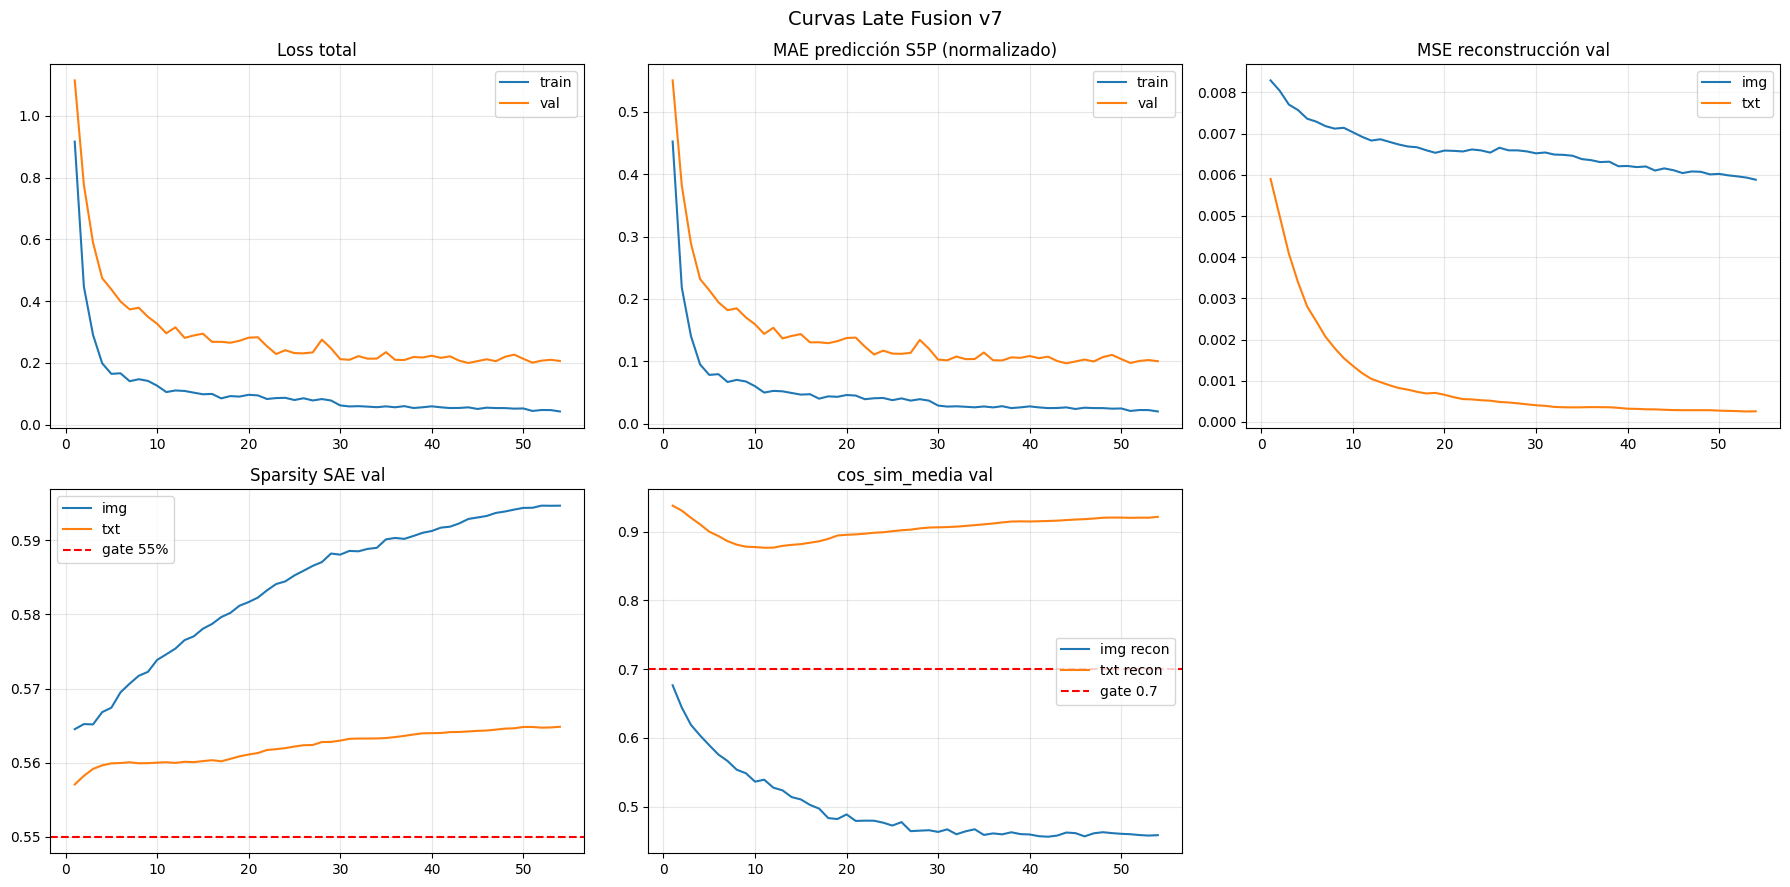

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
ep = history['epoch']

axes[0, 0].plot(ep, history['train_total'], label='train')
axes[0, 0].plot(ep, history['val_total'],   label='val')
axes[0, 0].set_title('Loss total'); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(ep, history['train_mae_pred'], label='train')
axes[0, 1].plot(ep, history['val_mae_pred'],   label='val')
axes[0, 1].set_title('MAE predicción S5P (normalizado)'); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

axes[0, 2].plot(ep, history['val_mse_img'], label='img')
axes[0, 2].plot(ep, history['val_mse_txt'], label='txt')
axes[0, 2].set_title('MSE reconstrucción val'); axes[0, 2].legend(); axes[0, 2].grid(alpha=0.3)

axes[1, 0].plot(ep, history['val_sparsity_img'], label='img')
axes[1, 0].plot(ep, history['val_sparsity_txt'], label='txt')
axes[1, 0].axhline(GATE_SPARSITY_MIN, color='r', linestyle='--', label=f'gate {GATE_SPARSITY_MIN:.0%}')
axes[1, 0].set_title('Sparsity SAE val'); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(ep, history['val_cos_sim_img'], label='img recon')
axes[1, 1].plot(ep, history['val_cos_sim_txt'], label='txt recon')
axes[1, 1].axhline(GATE_COS_SIM_MAX, color='r', linestyle='--', label=f'gate {GATE_COS_SIM_MAX}')
axes[1, 1].set_title('cos_sim_media val'); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

axes[1, 2].axis('off')
plt.suptitle('Curvas Late Fusion v7', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'curvas_v7.png', dpi=120, bbox_inches='tight')
plt.show()


## 12 - Validación de gates (precondición Fase 2)

In [12]:
model.load_state_dict(torch.load(OUTPUT_DIR / 'late_fusion_best.pt', map_location=device))
model.eval()

# Recalcular métricas finales sobre val (con W_L1 nominal, sin warmup ni reanim)
final = run_epoch(val_loader, train=False, epoch=-1)

# MAE NO2 desnormalizado
@torch.no_grad()
def compute_mae_per_pollutant(loader):
    preds, targs = [], []
    for batch in loader:
        imgs, s5p_vec, tokens, _ = batch
        imgs = imgs.to(device); s5p_vec = s5p_vec.to(device)
        emb_s2  = extract_image_emb_frozen(imgs)
        emb_txt = extract_text_emb_frozen(tokens)
        s5p_norm = normalize_s5p(s5p_vec)
        out = model(emb_s2, s5p_norm, emb_txt)
        pred = model.gru(out['emb_fusion'].unsqueeze(1).expand(-1, GRU_WINDOW, -1))
        preds.append(denormalize_s5p(pred).cpu().numpy())
        targs.append(s5p_vec.cpu().numpy())
    return np.concatenate(preds), np.concatenate(targs)

preds_v, targs_v = compute_mae_per_pollutant(val_loader)
mae_per = np.abs(preds_v - targs_v).mean(axis=0)
std_per = targs_v.std(axis=0) + 1e-8
ratio   = mae_per / std_per

print('MAE val (desnormalizado):')
for i, name in enumerate(['NO2', 'SO2', 'O3']):
    print(f'  {name}: MAE={mae_per[i]:.4e} | std={std_per[i]:.4e} | ratio={ratio[i]:.3f}')

# Gates v8: sparsity con rango [GATE_SPARSITY_MIN, GATE_SPARSITY_MAX] (Ferro Clase 33)
def _in_range(v, lo, hi):
    return lo <= v <= hi

gate_results = {
    'cos_sim_img':   final['cos_sim_img'] < GATE_COS_SIM_MAX,
    'cos_sim_txt':   final['cos_sim_txt'] < GATE_COS_SIM_MAX,
    'sparsity_img':  _in_range(final['sparsity_img'], GATE_SPARSITY_MIN, GATE_SPARSITY_MAX),
    'sparsity_txt':  _in_range(final['sparsity_txt'], GATE_SPARSITY_MIN, GATE_SPARSITY_MAX),
    'mae_NO2_ratio': ratio[0] < GATE_MAE_NO2_RATIO,
}
print('\nGate Fase 1 -> Fase 2 (parcial, falta skill score):')
for k, v in gate_results.items():
    marca = 'OK' if v else 'FAIL'
    print(f'  [{marca}] {k}')

gate_partial_pass = all(gate_results.values())
print(f'\nGate parcial: {"PASA (esperando skill score)" if gate_partial_pass else "NO PASA"}')

# Guardar métricas parciales; el bloque rolling-origin completa el JSON con el skill score
metricas_v8 = {
    'cos_sim_img':       float(final['cos_sim_img']),
    'cos_sim_txt':       float(final['cos_sim_txt']),
    'sparsity_img':      float(final['sparsity_img']),
    'sparsity_txt':      float(final['sparsity_txt']),
    'mae_NO2':           float(mae_per[0]),
    'mae_SO2':           float(mae_per[1]),
    'mae_O3':            float(mae_per[2]),
    'std_NO2':           float(std_per[0]),
    'std_SO2':           float(std_per[1]),
    'std_O3':            float(std_per[2]),
    'mae_NO2_ratio':     float(ratio[0]),
    'gate_partial_pass': bool(gate_partial_pass),
    'gate_results':      {k: bool(v) for k, v in gate_results.items()},
}


val:   0%|          | 0/5 [00:00<?, ?it/s]

MAE val (desnormalizado):
  NO2: MAE=7.6235e-07 | std=1.4760e-05 | ratio=0.052
  SO2: MAE=3.7435e-05 | std=3.5976e-04 | ratio=0.104
  O3: MAE=5.6488e-04 | std=6.9773e-03 | ratio=0.081

Gate Fase 1 -> Fase 2 (parcial, falta skill score):
  [OK] cos_sim_img
  [FAIL] cos_sim_txt
  [OK] sparsity_img
  [OK] sparsity_txt
  [OK] mae_NO2_ratio

Gate parcial: NO PASA


## 12b - Rolling-origin validation y persistence baseline

Validación temporal complementaria al gate base. Implementa walk-forward con
`TimeSeriesSplit` sobre el `full_dataset` ordenado por fecha y compara contra un
**persistence baseline** (predecir el valor del día D usando el valor observado
del día D-1 en el mismo tile geográfico). El skill score mayor o igual a 0 indica
que el modelo aporta valor real frente al baseline ingenuo. Patrón tomado de la
literatura de pronóstico de calidad del aire (Sun et al. 2022, IEEE TGRS).

Se ejecuta después de cargar `late_fusion_best.pt` para que el modelo evaluado
sea el de mejor checkpoint, no el del último epoch.


In [13]:
from sklearn.model_selection import TimeSeriesSplit


# Ordenar dataset por fecha para rolling-origin (fechas vacias al final, fuera de los folds)
all_dates_sorted_pairs = sorted(
    [(r.get('date', ''), i) for i, r in enumerate(full_dataset.records)],
    key=lambda x: (x[0] == '', x[0])
)
all_dates_sorted = [d for d, _ in all_dates_sorted_pairs]
pos_to_global    = {pos: glob_idx for pos, (_, glob_idx) in enumerate(all_dates_sorted_pairs)}


@torch.no_grad()
def rolling_origin_predict(model, full_dataset, val_positions, pos_to_global):
    # Predice S5P (desnormalizado) para cada posicion en val_positions y devuelve el target.
    # val_positions: array de indices en all_dates_sorted (ya filtrado por TimeSeriesSplit)
    model.eval()
    preds, targs, idxs_used = [], [], []
    for pos in val_positions:
        global_idx = pos_to_global[pos]
        img_t, s5p_vec, tokens, _meta = full_dataset[global_idx]
        img_t    = img_t.unsqueeze(0).to(device)
        tokens   = tokens.unsqueeze(0).to(device)
        s5p_vec  = s5p_vec.unsqueeze(0).to(device)
        emb_s2   = extract_image_emb_frozen(img_t)
        emb_txt  = extract_text_emb_frozen(tokens)
        s5p_norm = normalize_s5p(s5p_vec)
        out      = model(emb_s2, s5p_norm, emb_txt)
        pred     = model.gru(out['emb_fusion'].unsqueeze(1).expand(-1, GRU_WINDOW, -1))
        pred_dn  = denormalize_s5p(pred).cpu().numpy()[0]
        preds.append(pred_dn)
        targs.append(s5p_vec.cpu().numpy()[0])
        idxs_used.append(global_idx)
    return np.array(preds), np.array(targs), idxs_used


def persistence_baseline(full_dataset, idxs_used):
    # Baseline: predice el valor del mismo tile en la fecha previa más cercana.
    # Si no hay fecha previa para ese tile, repite el valor actual (cold-start).
    bucket = defaultdict(list)
    for i, r in enumerate(full_dataset.records):
        key = (round(float(r.get('lat_centroid', 0.0)), 3),
               round(float(r.get('lon_centroid', 0.0)), 3))
        bucket[key].append((r.get('date', ''), i))
    for k in bucket:
        bucket[k].sort()

    preds = []
    for idx in idxs_used:
        rec = full_dataset.records[idx]
        key = (round(float(rec.get('lat_centroid', 0.0)), 3),
               round(float(rec.get('lon_centroid', 0.0)), 3))
        date_actual = rec.get('date', '')
        prev_val = None
        for d, i_prev in bucket[key]:
            if d < date_actual and i_prev != idx:
                rec_prev = full_dataset.records[i_prev]
                prev_val = [float(rec_prev['val_no2']),
                            float(rec_prev['val_so2']),
                            float(rec_prev['val_o3'])]
            elif d >= date_actual:
                break
        if prev_val is None:
            prev_val = [float(rec['val_no2']),
                        float(rec['val_so2']),
                        float(rec['val_o3'])]
        preds.append(prev_val)
    return np.array(preds)


n_splits = 5
positions = np.arange(len(all_dates_sorted))
tscv = TimeSeriesSplit(n_splits=n_splits, gap=GRU_WINDOW)

mae_model_folds    = []
mae_baseline_folds = []
for fold_id, (_, val_pos) in enumerate(tscv.split(positions)):
    preds_m, targs_m, idxs_used = rolling_origin_predict(
        model, full_dataset, val_pos, pos_to_global
    )
    preds_b = persistence_baseline(full_dataset, idxs_used)

    # Solo NO2 para el skill score principal
    mae_m_no2 = float(np.abs(preds_m[:, 0] - targs_m[:, 0]).mean())
    mae_b_no2 = float(np.abs(preds_b[:, 0] - targs_m[:, 0]).mean())
    mae_model_folds.append(mae_m_no2)
    mae_baseline_folds.append(mae_b_no2)
    print(f'  Fold {fold_id+1}: MAE_NO2 modelo={mae_m_no2:.4e} | baseline={mae_b_no2:.4e}')

mae_model_avg    = float(np.mean(mae_model_folds))
mae_baseline_avg = float(np.mean(mae_baseline_folds))
skill_score      = 1.0 - (mae_model_avg / (mae_baseline_avg + 1e-12))

print()
print(f'Rolling-origin NO2  | modelo avg  : {mae_model_avg:.4e}')
print(f'Rolling-origin NO2  | baseline avg: {mae_baseline_avg:.4e}')
print(f'Skill score (>= {GATE_PERSISTENCE_SKILL_MIN}): {skill_score:.4f}')

gate_skill_pass = skill_score >= GATE_PERSISTENCE_SKILL_MIN
print(f'Gate persistence    : {"OK" if gate_skill_pass else "FAIL"}')


  Fold 1: MAE_NO2 modelo=1.3017e-07 | baseline=1.5578e-05
  Fold 2: MAE_NO2 modelo=1.6988e-07 | baseline=1.6131e-05
  Fold 3: MAE_NO2 modelo=2.1717e-07 | baseline=1.3953e-05
  Fold 4: MAE_NO2 modelo=1.6397e-07 | baseline=1.8542e-05
  Fold 5: MAE_NO2 modelo=7.3313e-07 | baseline=1.8051e-05

Rolling-origin NO2  | modelo avg  : 2.8286e-07
Rolling-origin NO2  | baseline avg: 1.6451e-05
Skill score (>= 0.0): 0.9828
Gate persistence    : OK


## 12c - Gate global Fase 1 -> Fase 2 (cierre v8)

Unifica gates de val, rango sparsity Ferro y skill score rolling-origin.
Persiste `métricas_v8.json` con todos los valores observados, decisión por gate
y la decisión global. Si pasa, la Fase 2 (cokriging) puede consumir el output
sin renegociar criterios.


In [14]:
# Gate global v8: une gates v7 (cos_sim, sparsity_range, mae_NO2) + skill score rolling-origin
metricas_v8['skill_score_NO2']      = float(skill_score)
metricas_v8['mae_rolling_model']    = float(mae_model_avg)
metricas_v8['mae_rolling_baseline'] = float(mae_baseline_avg)
metricas_v8['gate_skill_pass']      = bool(gate_skill_pass)
metricas_v8['gate_results']['skill_score'] = bool(gate_skill_pass)

gate_global_pass = metricas_v8['gate_partial_pass'] and metricas_v8['gate_skill_pass']
metricas_v8['gate_global_pass']     = bool(gate_global_pass)

print('\nResumen gates v8:')
for k, v in metricas_v8['gate_results'].items():
    marca = 'OK' if v else 'FAIL'
    print(f'  [{marca}] {k}')
print(f'\nGate global v8: {"PASA - listo para Fase 2 (cokriging)" if gate_global_pass else "NO PASA - iterar D antes de tocar Fase 2"}')

# Persistir métricas_v8.json
import json as _json
metrics_path = OUTPUT_DIR / 'metricas_v8.json'
with open(metrics_path, 'w', encoding='utf-8') as _f:
    _json.dump(metricas_v8, _f, ensure_ascii=False, indent=2)
print(f'\nMétricas guardadas en: {metrics_path}')



Resumen gates v8:
  [OK] cos_sim_img
  [FAIL] cos_sim_txt
  [OK] sparsity_img
  [OK] sparsity_txt
  [OK] mae_NO2_ratio
  [OK] skill_score

Gate global v8: NO PASA - iterar D antes de tocar Fase 2

Métricas guardadas en: D:\analitica\outputs_geovision\v8_latefusion\metricas_v8.json


## 13 - Generar predicciones GRU sobre dataset completo (input Fase 2)

In [15]:
@torch.no_grad()
def predict_full(records, full_ds):
    preds_records = []
    full_loader_seq = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=False)
    rec_iter = iter(records)
    for batch in tqdm(full_loader_seq, desc='predict full'):
        imgs, s5p_vec, tokens, meta = batch
        B = imgs.shape[0]
        imgs = imgs.to(device); s5p_vec = s5p_vec.to(device)
        emb_s2  = extract_image_emb_frozen(imgs)
        emb_txt = extract_text_emb_frozen(tokens)
        s5p_norm = normalize_s5p(s5p_vec)
        out = model(emb_s2, s5p_norm, emb_txt)
        pred_n = model.gru(out['emb_fusion'].unsqueeze(1).expand(-1, GRU_WINDOW, -1))
        pred   = denormalize_s5p(pred_n).cpu().numpy()
        for b in range(B):
            preds_records.append({
                'pair_id': meta['pair_id'][b],
                'tile_id': int(meta['tile_id'][b]),
                'fecha':   meta['date'][b],
                'lat':     float(meta['lat'][b]),
                'lon':     float(meta['lon'][b]),
                'P_NO2':   float(pred[b, 0]),
                'P_SO2':   float(pred[b, 1]),
                'P_O3':    float(pred[b, 2]),
            })
    return preds_records


pred_records = predict_full(full_dataset.records, full_dataset)
df_pred = pd.DataFrame(pred_records)
print(f'Predicciones generadas: {len(df_pred):,}')
print(df_pred.head())

OUT_PRED = OUTPUT_DIR / 'predicciones_gru.parquet'
df_pred.to_parquet(OUT_PRED, index=False)
print(f'Persistido: {OUT_PRED}')


predict full:   0%|          | 0/31 [00:00<?, ?it/s]

Predicciones generadas: 990
                                  pair_id  tile_id       fecha       lat  \
0  high_NO2_pollution_2022-06-05_181_0000      181  2022-06-05  3.121543   
1   high_NO2_pollution_2020-07-30_55_0001       55  2020-07-30  3.121543   
2  high_NO2_pollution_2023-11-27_235_0002      235  2023-11-27  3.121543   
3  high_NO2_pollution_2023-02-10_202_0003      202  2023-02-10  3.121543   
4   high_NO2_pollution_2020-10-23_77_0004       77  2020-10-23  3.121543   

         lon     P_NO2     P_SO2      P_O3  
0 -76.305557  0.000024  0.000043  0.116712  
1 -76.305557  0.000028  0.000003  0.119807  
2 -76.305557  0.000023 -0.000103  0.115248  
3 -76.305557  0.000021 -0.000071  0.114916  
4 -76.305557  0.000023  0.000003  0.117481  
Persistido: D:\analitica\outputs_geovision\v8_latefusion\predicciones_gru.parquet


## 14 - Trazabilidad MD5 de artefactos

In [16]:
def md5_file(path: Path) -> str:
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()


artefactos = [
    OUTPUT_DIR / 'late_fusion_best.pt',
    OUTPUT_DIR / 'curvas_v8.png',
    OUTPUT_DIR / 'predicciones_gru.parquet',
]

trazabilidad = {}
for p in artefactos:
    if p.exists():
        trazabilidad[p.name] = {'md5': md5_file(p), 'size_bytes': p.stat().st_size}
        print(f'{p.name}: md5={trazabilidad[p.name]["md5"]} size={trazabilidad[p.name]["size_bytes"]:,} B')

trazabilidad['gate_results']     = metricas_v8['gate_results']
trazabilidad['gate_global_pass'] = metricas_v8['gate_global_pass']
trazabilidad['mae_per_pollutant'] = {
    name: {'mae': float(mae_per[i]), 'std': float(std_per[i]), 'ratio': float(ratio[i])}
    for i, name in enumerate(['NO2', 'SO2', 'O3'])
}
trazabilidad['final_metrics']    = {k: float(v) for k, v in final.items()}
trazabilidad['rolling_origin']   = {
    'skill_score_NO2':      float(skill_score),
    'mae_rolling_model':    float(mae_model_avg),
    'mae_rolling_baseline': float(mae_baseline_avg),
}
trazabilidad['hiperparams'] = {
    'SEED': SEED, 'EXPANSION_FACTOR': EXPANSION_FACTOR, 'EXPANSION_DIM': EXPANSION_DIM,
    'BATCH_SIZE': BATCH_SIZE, 'LR': LR, 'WD': WD, 'GRU_WINDOW': GRU_WINDOW,
    'GRU_HIDDEN': GRU_HIDDEN, 'GRU_LAYERS': GRU_LAYERS,
    'W_RECON_IMG': W_RECON_IMG, 'W_RECON_TXT': W_RECON_TXT,
    'W_L1_IMG': W_L1_IMG, 'W_L1_TXT': W_L1_TXT, 'W_PRED': W_PRED,
    'L1_WARMUP_EPOCHS': L1_WARMUP_EPOCHS, 'REANIM_COEF': REANIM_COEF,
    'USE_TIME_SPLIT': USE_TIME_SPLIT, 'TIME_SPLIT_RATIO': TIME_SPLIT_RATIO,
    'TIME_SPLIT_GAP_DAYS': TIME_SPLIT_GAP_DAYS,
    'GATE_SPARSITY_MIN': GATE_SPARSITY_MIN, 'GATE_SPARSITY_MAX': GATE_SPARSITY_MAX,
    'GATE_PERSISTENCE_SKILL_MIN': GATE_PERSISTENCE_SKILL_MIN,
}

# Mezclar trazabilidad sobre el JSON ya guardado por la cell 12c
import json as _json
metrics_path = OUTPUT_DIR / 'metricas_v8.json'
if metrics_path.exists():
    with open(metrics_path, 'r', encoding='utf-8') as _f:
        existing = _json.load(_f)
    existing['trazabilidad'] = trazabilidad
    with open(metrics_path, 'w', encoding='utf-8') as _f:
        _json.dump(existing, _f, ensure_ascii=False, indent=2)
else:
    with open(metrics_path, 'w', encoding='utf-8') as _f:
        _json.dump({'trazabilidad': trazabilidad}, _f, ensure_ascii=False, indent=2)
print(f'\nTrazabilidad guardada en: {metrics_path}')


late_fusion_best.pt: md5=7799138c4f0c54d94b27a27c30f993c3 size=72,693,342 B
predicciones_gru.parquet: md5=73c51ec589df5fcacfb24c4cb01381fc size=40,167 B

Trazabilidad guardada en: D:\analitica\outputs_geovision\v8_latefusion\metricas_v8.json


## 15 - Próximos pasos

1. Revisar `metricas_v8.json` y confirmar `gate_global_pass`. Si es `True`, abrir notebook `04_Cokriging_Universal_Espacial.ipynb` (Fase 2). Si no, iterar sobre Late Fusion v8:
   - Si `cos_sim_txt` no baja: ampliar `MAGNITUDE_LEVELS`, `SEASONS_CALI` o `URBAN_CONTEXTS` (más diversidad textual); considerar paraphrasing con LLM al estilo LaCLIP.
   - Si `sparsity` queda por debajo del rango Ferro [0.55, 0.65]: subir `W_L1_IMG` o `W_L1_TXT` un orden de magnitud manteniendo asimetría; reentrenar.
   - Si `mae_NO2_ratio` se dispara bajo split temporal cronológico: confirmar que la pseudo-validación del v7 era leaky y reportar como hallazgo metodológico.
   - Si `skill_score_NO2` queda negativo: el modelo es peor que persistencia. Auditar el GRU (probable underfitting temporal) y considerar `GRU_WINDOW = 14`.

2. Si pseudo-RGB (`00_diag_pseudoRGB.ipynb`) indicó `A_OBLIGATORIO`, NO ejecutar este notebook antes de aplicar Camino A (tiling subscene). Nota: la Ronda 3 de investigación documentó que el SAE_img de v7 ya resolvió el colapso visual, por lo que el Camino A queda descartado para v8 a menos que la auditoría de embeddings post-train muestre lo contrario.

3. Las predicciones `predicciones_gru.parquet` alimentan el cokriging universal con `(lat, lon, fecha, P_NO2, P_SO2, P_O3)` como pseudo-observaciones. La columna `confianza` se deriva en Fase 2 a partir de la dispersión rolling-origin.

4. La interpretabilidad SAE (visualización de features dispersas activadas por nivel de magnitud, estación y contexto urbano) queda para una sección dedicada al notebook de análisis post-entrenamiento. Bajo el caption augmentation v8, cada feature debería alinearse con un cuadrante semántico interpretable.

5. Persistir un log explícito de qué cambios v8 hicieron pasar (o no) cada gate, en `agent-docs/handoffs/<fecha>/<fecha>-resultados-v8.md`, para alimentar la siguiente ronda de investigación si el gate global no cierra.
